<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/UMAP%20%C3%A9s%20Egy%C3%A9b%20Dimenzi%C3%B3cs%C3%B6kkent%C3%A9si%20M%C3%B3dszerek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UMAP és Egyéb Dimenziócsökkentési Módszerek


Az előző notebookban megnéztük a két klasszikust: a lineáris **PCA**-t és a vizualizációs **t-SNE**-t. Mindkettőnek vannak korlátai: a PCA csak lineáris struktúrát talál, a t-SNE pedig lassú, nem skálázható, és nem őrzi meg a globális topológiát.

A modern dimenziócsökkentés gazdag eszköztárat kínál:
- **UMAP**: gyors, globális+lokális, t-SNE-szerű vizualizáció
- **ISOMAP**: geodetikus távolságok globális megőrzése
- **LLE**: lokális lineáris újrakonstrukció
- **MDS**: páronkénti távolságok megőrzése
- **Random Projections**: matematikai garancia, nagyon gyors
- **Autoencoderek**: tanulható nemlineáris vetítés

## Tartalomjegyzék

1. Manifold-tanulás áttekintése
2. UMAP (Uniform Manifold Approximation and Projection)
3. ISOMAP
4. Locally Linear Embedding (LLE)
5. Multidimensional Scaling (MDS)
6. Random Projections
7. Autoencoderek (rövid bevezető)
8. Módszerek összehasonlítása

## 1. Manifold-tanulás áttekintése

### A manifold-feltevés

A magas dimenziós valós adatok ritkán töltik ki egyenletesen a teret: egy **alacsonyabb dimenziós sokaságra** (manifold) esnek. A manifold-tanulás célja ezt a sokaságot felfedezni és lapossá teríteni.

### A módszerek két nagy családja

| Család | Fókusz | Példák |
|--------|--------|--------|
| **Globális** | Páronkénti távolságok az egész adathalmazon | MDS, ISOMAP |
| **Lokális** | Lokális szomszédsági viszonyok | LLE, t-SNE, UMAP |

### Mit jelent a "lokális"?

Egy módszer **lokális**, ha minden pontnak csak a kicsi környezetét veszi figyelembe (pl. $k$ legközelebbi szomszédait). A kompozíció során ezek a kis foltok illeszkednek össze egy globális vetületté.

### Időbonyolultság sokszor a kritikus szempont

| Módszer | Becsült bonyolultság (n minta, d dimenzió, k szomszéd) |
|---------|--------------------------------------------------------|
| PCA | $O(\min(nd^2, n^2 d))$ |
| t-SNE (Barnes-Hut) | $O(n \log n)$ |
| UMAP | $O(d^{1.14} n^{1.14})$ empirikusan |
| MDS | $O(n^3)$ |
| ISOMAP | $O(n^2 \log n)$ (KNN után Dijkstra) |
| LLE | $O(d \log k \cdot n \log n + d n k^3)$ |

### Szükséges importok

In [ ]:
!pip install --q umap-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits, make_swiss_roll, make_s_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS
from sklearn.random_projection import GaussianRandomProjection
import umap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)

%matplotlib inline

## Adathalmazok

A módszerek demonstrálásához két adathalmazt használunk:
1. **Swiss roll**: szintetikus 3D nemlineáris sokaság, ahol a szín a sokaság menti pozíciót jelöli
2. **MNIST számjegyek**: 64-dimenziós valós osztályozási adat

Swiss roll: (1500, 3)
S-curve: (1500, 3)
Digits: (1797, 64) (alminta: (800, 64))


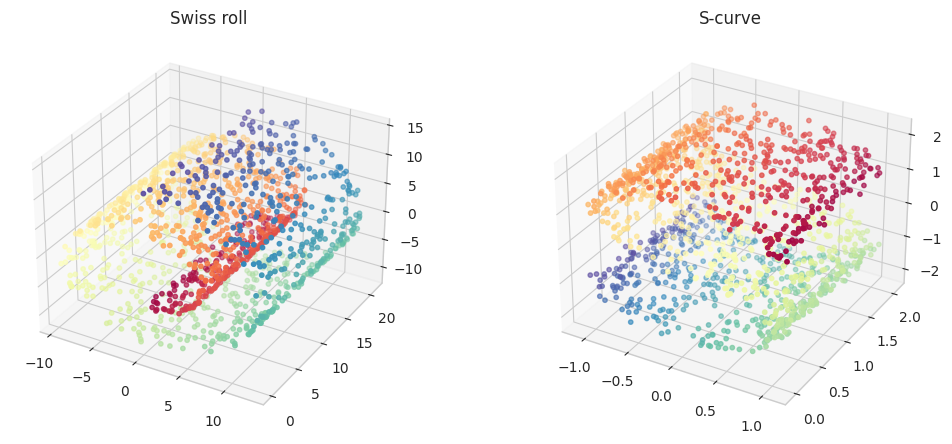

In [ ]:
# Adatok
X_sr, color_sr = make_swiss_roll(n_samples=1500, noise=0.05, random_state=0)
X_sc, color_sc = make_s_curve(n_samples=1500, noise=0.05, random_state=0)

digits = load_digits()
X_dig = digits.data
y_dig = digits.target

# Alminta a számjegyekből, hogy gyorsabb legyen az MDS
rng = np.random.default_rng(0)
sub_idx = rng.choice(len(X_dig), 800, replace=False)
X_dig_sub = X_dig[sub_idx]
y_dig_sub = y_dig[sub_idx]

print(f"Swiss roll: {X_sr.shape}")
print(f"S-curve: {X_sc.shape}")
print(f"Digits: {X_dig.shape} (alminta: {X_dig_sub.shape})")

# A 3D sokaságok megjelenítése
fig = plt.figure(figsize=(11, 4.5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=color_sr, cmap='Spectral', s=10)
ax1.set_title('Swiss roll')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_sc[:, 0], X_sc[:, 1], X_sc[:, 2], c=color_sc, cmap='Spectral', s=10)
ax2.set_title('S-curve')

plt.tight_layout()
plt.show()

## 2. UMAP (Uniform Manifold Approximation and Projection)

Az **UMAP** (McInnes, Healy & Melville, 2018) az egyik legnépszerűbb modern dimenziócsökkentési módszer. Topológiai matematikára épül, gyorsabb, mint a t-SNE, és jobban őrzi a globális struktúrát is.

### Az algoritmus dióhéjban

1. **Magas dimenziós gráf építése**: minden pontra kiszámítjuk a $k$ legközelebbi szomszédot, és súlyozott éleket képezünk lokálisan adaptív Riemann-metrika alapján
2. **Szimmetrizálás**: az élek súlyait szimmetrikusra tesszük (fuzzy union)
3. **Alacsony dimenziós gráf optimalizálása**: az alacsony dimenziós beágyazást úgy hangoljuk, hogy a két gráf hasonló legyen (cross-entropy)
4. **Sztochasztikus gradient descent**: gyors, mini-batch optimalizálás

### Fontos hiperparaméterek

| Paraméter | Hatás | Tipikus érték |
|-----------|-------|---------------|
| `n_neighbors` | Mennyi szomszédot tekint lokálisnak | 5 (lokálisabb) - 50 (globálisabb) |
| `min_dist` | Mennyire szorulnak össze a klaszterek | 0.0 (sűrű) - 0.99 (lazább) |
| `metric` | Távolságmetrika | 'euclidean', 'cosine', 'manhattan' |

### t-SNE vs UMAP

| Szempont | t-SNE | UMAP |
|----------|-------|------|
| **Sebesség** | Lassabb | Gyorsabb (gyakran 5-10x) |
| **Globális struktúra** | Gyenge | Jobb |
| **Reprodukálhatóság** | Stochasztikus | Stochasztikus, de seedelhető |
| **Új adatra alkalmazás** | NEM | IGEN (`.transform()`) |
| **Matematikai alap** | Valószínűségi (KL) | Topológiai (cross-entropy) |

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


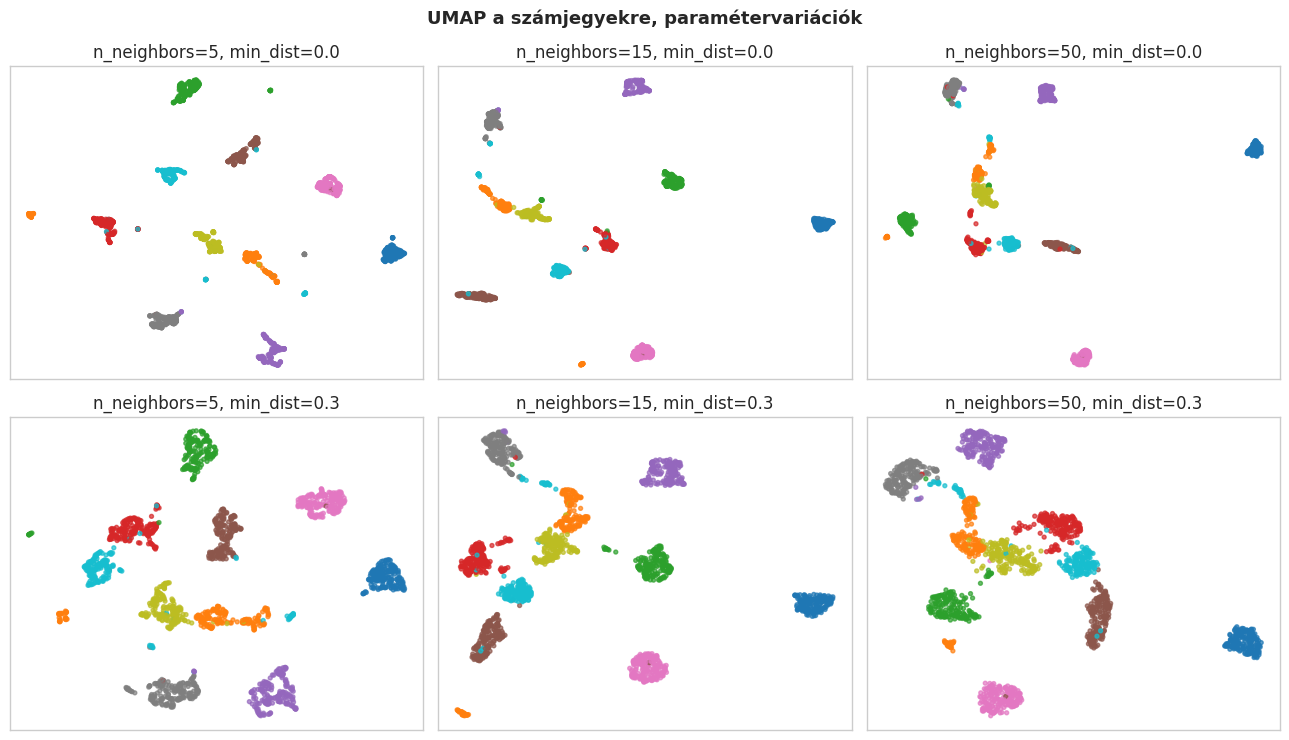

In [ ]:
# UMAP a számjegyekre, különböző paraméterekkel

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

n_neighbors_list = [5, 15, 50]
min_dist_list = [0.0, 0.3]

for i, min_d in enumerate(min_dist_list):
    for j, n_n in enumerate(n_neighbors_list):
        reducer = umap.UMAP(n_neighbors=n_n, min_dist=min_d,
                            n_components=2, random_state=0)
        Z = reducer.fit_transform(X_dig)
        ax = axes[i, j]
        sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_dig, cmap='tab10', s=8, alpha=0.7)
        ax.set_title(f'n_neighbors={n_n}, min_dist={min_d}')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('UMAP a számjegyekre, paramétervariációk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


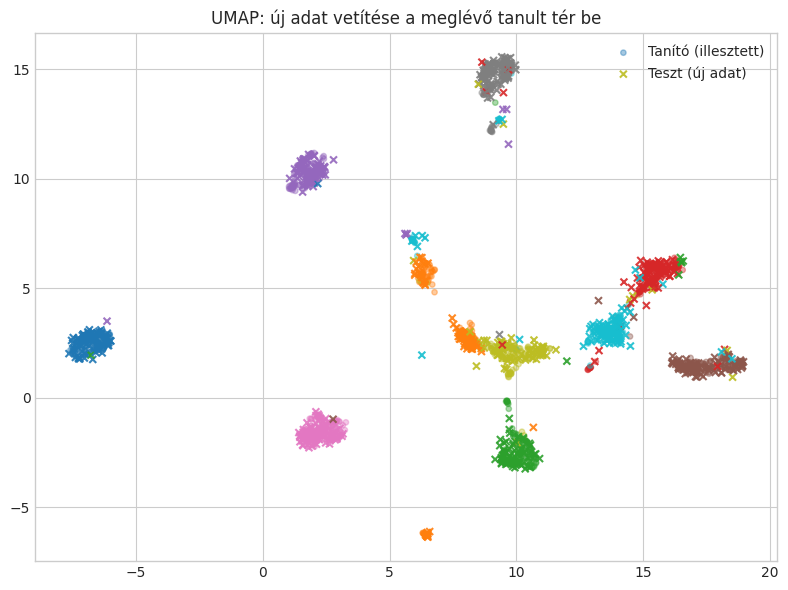

In [ ]:
# UMAP új adatra: transform() használata
# Tanítás csak az adat felén; a másik fél új pontként vetítve
split = len(X_dig) // 2
X_train, X_test = X_dig[:split], X_dig[split:]
y_train, y_test = y_dig[:split], y_dig[split:]

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=0)
Z_train = reducer.fit_transform(X_train)
Z_test = reducer.transform(X_test)  # új adat vetítése!

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Z_train[:, 0], Z_train[:, 1], c=y_train, cmap='tab10',
           s=15, alpha=0.4, label='Tanító (illesztett)')
ax.scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, cmap='tab10',
           s=25, alpha=0.9, marker='x', label='Teszt (új adat)')
ax.set_title('UMAP: új adat vetítése a meglévő tanult tér be')
ax.legend()
plt.tight_layout()
plt.show()

## 3. ISOMAP

Az **ISOMAP** (Tenenbaum, de Silva & Langford, 2000) az MDS általánosítása görbült sokaságokra. Az alapötlet: a páronkénti távolságot **a sokaság mentén** mérjük, nem egyenes vonalban.

### Algoritmus

1. **Szomszédsági gráf**: minden ponthoz a $k$ legközelebbi szomszéd egyenes távolsága
2. **Geodetikus távolságok**: Dijkstra/Floyd-Warshall a gráfon $\Rightarrow$ páronkénti **geodetikus** távolság
3. **Klasszikus MDS** ezekre a távolságokra

### Mikor jó?

- **Sima, jól mintavételezett sokaság** (pl. swiss roll)
- **Globális geometria fontos**

### Mikor nem jó?

- **Lyukas vagy elszakadt sokaság**: a gráf rosszul közelíti a geodetikust
- **Nagy zaj**: a szomszédsági struktúra elromlik

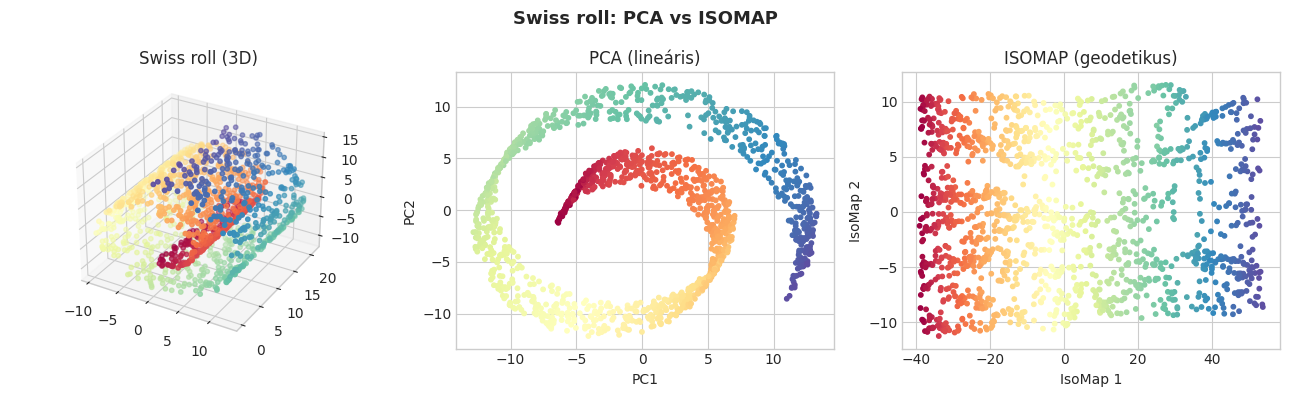

In [ ]:
# ISOMAP a swiss roll-ra
iso = Isomap(n_neighbors=10, n_components=2)
Z_iso_sr = iso.fit_transform(X_sr)

# Összehasonlítás PCA-val
pca = PCA(n_components=2)
Z_pca_sr = pca.fit_transform(X_sr)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=color_sr, cmap='Spectral', s=10)
ax1.set_title('Swiss roll (3D)')

axes[1].scatter(Z_pca_sr[:, 0], Z_pca_sr[:, 1], c=color_sr, cmap='Spectral', s=10)
axes[1].set_title('PCA (lineáris)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

axes[2].scatter(Z_iso_sr[:, 0], Z_iso_sr[:, 1], c=color_sr, cmap='Spectral', s=10)
axes[2].set_title('ISOMAP (geodetikus)')
axes[2].set_xlabel('IsoMap 1'); axes[2].set_ylabel('IsoMap 2')

# Az első ax csúnyán illeszkedik a subplot-ba a 3D miatt; tisztítsuk
axes[0].axis('off')

plt.suptitle('Swiss roll: PCA vs ISOMAP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Locally Linear Embedding (LLE)

Az **LLE** (Roweis & Saul, 2000) lokális szempontból dolgozik. Minden pontot a szomszédai **lineáris kombinációjaként** rekonstruálunk; ezeket a rekonstrukciós súlyokat őrizzük meg.

### Algoritmus

1. Minden $x_i$ ponthoz keressük meg a $k$ legközelebbi szomszédot
2. Számoljuk ki azokat a $w_{ij}$ súlyokat, amelyekre $x_i \approx \sum_j w_{ij} x_j$ legjobban illik (legkisebb négyzetes hiba)
3. Keressünk olyan alacsony dimenziós $y_i$ pontokat, amelyek ugyanezeket a súlyokat őrzik meg: $y_i \approx \sum_j w_{ij} y_j$

### Erősségek és gyengeségek

- Egyszerű, csak helyi információt használ
- Sima sokaságokon jó eredményt ad
- Érzékeny a $k$ szomszédszámra
- A súlymátrix sajátérték-feladatát kell megoldani

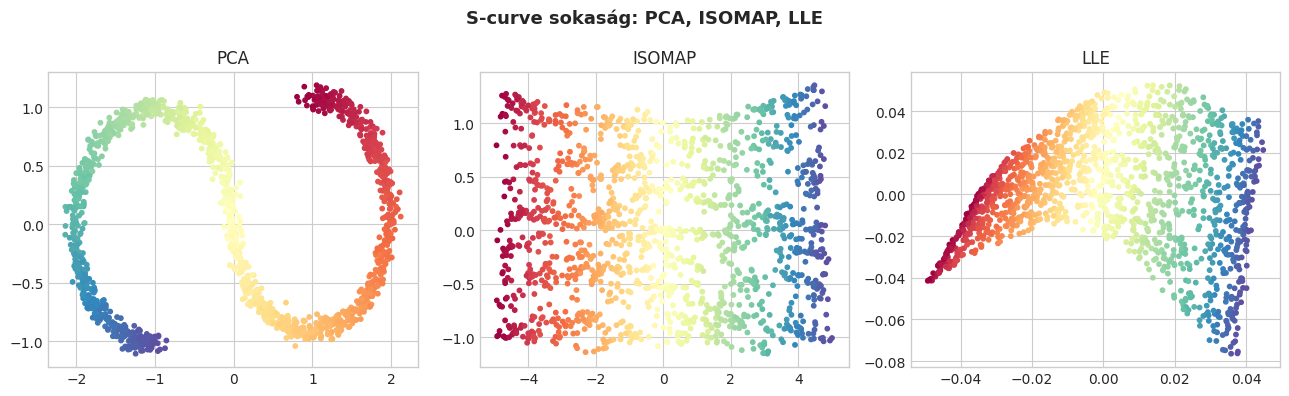

In [ ]:
# LLE az S-curve-re

lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, method='standard')
Z_lle_sc = lle.fit_transform(X_sc)

iso2 = Isomap(n_neighbors=12, n_components=2)
Z_iso_sc = iso2.fit_transform(X_sc)

pca2 = PCA(n_components=2)
Z_pca_sc = pca2.fit_transform(X_sc)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(Z_pca_sc[:, 0], Z_pca_sc[:, 1], c=color_sc, cmap='Spectral', s=10)
axes[0].set_title('PCA')

axes[1].scatter(Z_iso_sc[:, 0], Z_iso_sc[:, 1], c=color_sc, cmap='Spectral', s=10)
axes[1].set_title('ISOMAP')

axes[2].scatter(Z_lle_sc[:, 0], Z_lle_sc[:, 1], c=color_sc, cmap='Spectral', s=10)
axes[2].set_title('LLE')

plt.suptitle('S-curve sokaság: PCA, ISOMAP, LLE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Multidimensional Scaling (MDS)

A **klasszikus MDS** közvetlenül a páronkénti távolságokat próbálja megőrizni. Adott egy $D \in \mathbb{R}^{n \times n}$ távolságmátrix, keressük azt a $Y$ alacsony dimenziós beágyazást, amelyre $\|y_i - y_j\| \approx D_{ij}$.

### Klasszikus MDS (metric MDS)

Ha a $D_{ij}^2$ négyzetes távolságokat használjuk, az MDS megoldása **PCA**-val ekvivalens (a centrált belső szorzat mátrix sajátfelbontása).

### Stress-alapú MDS

Általánosabb veszteségfüggvény:

$$\text{Stress}(Y) = \sum_{i < j} (D_{ij} - \|y_i - y_j\|)^2$$

Ezt iteratíven minimalizáljuk. Skálázza a nemlineáris távolságokat (pl. ISOMAP geodetikusait).

### Korlát

A klasszikus MDS $O(n^3)$, ami $n > 5000$-re már problematikus.

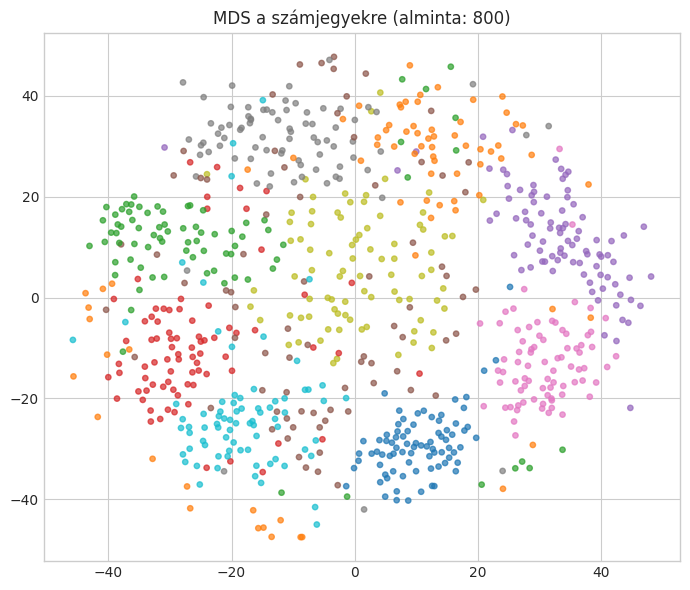

In [ ]:
# MDS a számjegyek almintáján
mds = MDS(n_components=2, n_init=2, random_state=0, normalized_stress='auto')
Z_mds = mds.fit_transform(X_dig_sub)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Z_mds[:, 0], Z_mds[:, 1], c=y_dig_sub, cmap='tab10', s=15, alpha=0.7)
ax.set_title(f'MDS a számjegyekre (alminta: {len(X_dig_sub)})')
plt.tight_layout()
plt.show()

## 6. Random Projections

Egyszerű, mégis matematikailag erős módszer: **véletlen lineáris vetítés**. A **Johnson-Lindenstrauss lemma** szerint egy megfelelően nagy $k$ dimenziós véletlen vetület megőrzi a páronkénti távolságokat tetszőleges $\epsilon$ relatív hibahatárral, ahol:

$$k \geq \frac{8 \ln n}{\epsilon^2}$$

### Tulajdonságok

| Szempont | Érték |
|----------|-------|
| **Lineáris?** | Igen |
| **Tanítás kell?** | Nem (csak véletlen mátrix) |
| **Sebesség** | Nagyon gyors |
| **Optimalitás** | Várhatóan közelítő |
| **Adatfüggetlen** | Igen (nem használja $X$-et a vetítéshez) |

### Mikor használjuk?

- Streaming, online ML
- Nagy adat előfeldolgozása más DR előtt
- Privacy-preserving adatmegosztás

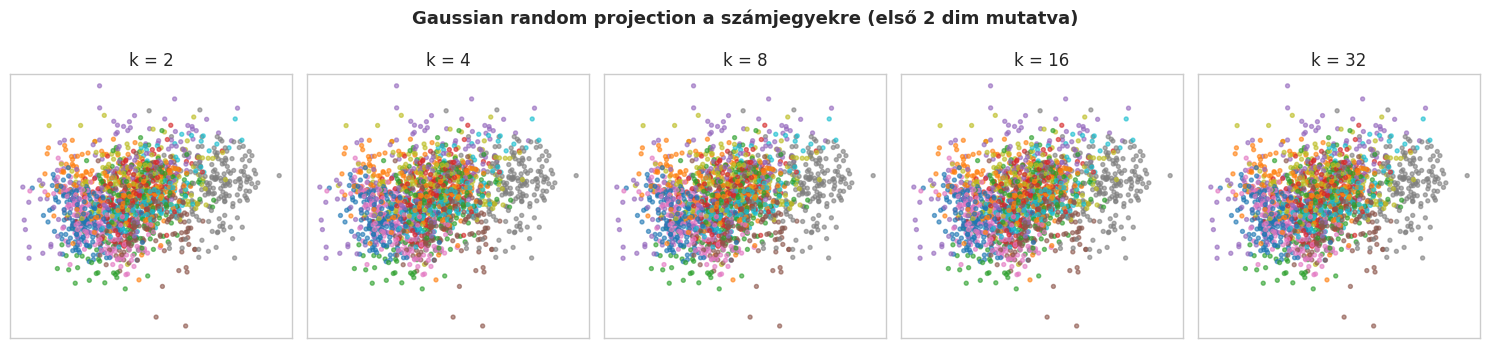

In [ ]:
# Random projection a számjegyekre
dim_targets = [2, 4, 8, 16, 32]
fig, axes = plt.subplots(1, len(dim_targets), figsize=(15, 3.5))

for ax, dim in zip(axes, dim_targets):
    rp = GaussianRandomProjection(n_components=dim, random_state=0)
    Z_rp = rp.fit_transform(X_dig)
    # Vizualizációhoz az első 2-t mutatjuk
    sc = ax.scatter(Z_rp[:, 0], Z_rp[:, 1], c=y_dig, cmap='tab10', s=8, alpha=0.6)
    ax.set_title(f'k = {dim}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Gaussian random projection a számjegyekre (első 2 dim mutatva)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Autoencoderek (rövid bevezető)

Az **autoencoder** egy neurális háló, amely megtanulja az adat tömör reprezentációját:

$$\text{enkóder } f: \mathbb{R}^d \to \mathbb{R}^k, \quad \text{dekóder } g: \mathbb{R}^k \to \mathbb{R}^d$$

A tanítás célja: $g(f(x)) \approx x$ az összes adatpontra. A $k$-dimenziós **kód** $f(x)$ adja a dimenziócsökkentést.

### Variánsok

| Típus | Cél |
|-------|-----|
| **Vanilla AE** | Egyszerű rekonstrukció |
| **Sparse AE** | Ritka kódot tanul (regularizáció) |
| **Denoising AE** | Zajos bemenetből tisztát rekonstruál |
| **Variational AE (VAE)** | Generatív modell, valószínűségi kód |
| **Contractive AE** | A kód érzéketlen kis input-perturbációkra |

### Előnyök és hátrányok

- Nemlineáris, nagy adatokon skálázható
- Új adatra alkalmazható (a háló tanult)
- Hangolása nehéz (architektúra, regularizáció)
- A kód térben a távolság nem feltétlenül értelmes

A teljes implementáció külön notebookot érdemelne (pl. PyTorch-csal). Itt csak a koncepciót illusztráljuk a PCA-val való párhuzamon: egy lineáris autoencoder pontosan ekvivalens a PCA-val (legalábbis hossz szerint).

PCA mint lineáris autoencoder, k=10
  Rekonstrukciós MSE: 46.1980


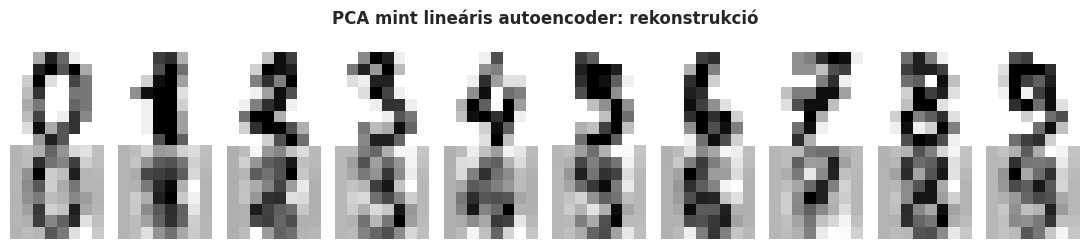

In [ ]:
# Lineáris "autoencoder" PCA-val: az egyenlet látható
# A PCA W mátrixa (komponensek soraiként): k x d
# Az encoder: z = (x - mu) @ W^T
# A decoder: x_hat = z @ W + mu
# Ez egy lineáris autoencoder, amelyet a kvadratikus rekonstrukciós hiba minimalizál.
X_centered = X_dig - X_dig.mean(0)
pca_ae = PCA(n_components=10).fit(X_centered)

z = pca_ae.transform(X_centered)
x_hat = pca_ae.inverse_transform(z)
recon_err = np.mean((X_centered - (x_hat - X_dig.mean(0))) ** 2)
print(f"PCA mint lineáris autoencoder, k=10")
print(f"  Rekonstrukciós MSE: {recon_err:.4f}")

# Megjelenítés
n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(11, 2.5))
for i in range(n_show):
    axes[0, i].imshow(X_dig[i].reshape(8, 8), cmap='gray_r')
    axes[0, i].axis('off')
    rec = pca_ae.inverse_transform(pca_ae.transform(X_dig[i:i+1]))[0]
    axes[1, i].imshow(rec.reshape(8, 8), cmap='gray_r')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Eredeti', rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('Rekon (k=10)', rotation=0, ha='right', va='center')
plt.suptitle('PCA mint lineáris autoencoder: rekonstrukció', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Módszerek összehasonlítása

A számjegyeken egyszerre futtatjuk a fontosabb módszereket, és vizuálisan + időben hasonlítjuk őket.

  PCA fut...
  t-SNE fut...
  UMAP fut...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ISOMAP fut...
  LLE fut...
  MDS fut...
  Random Proj. fut...


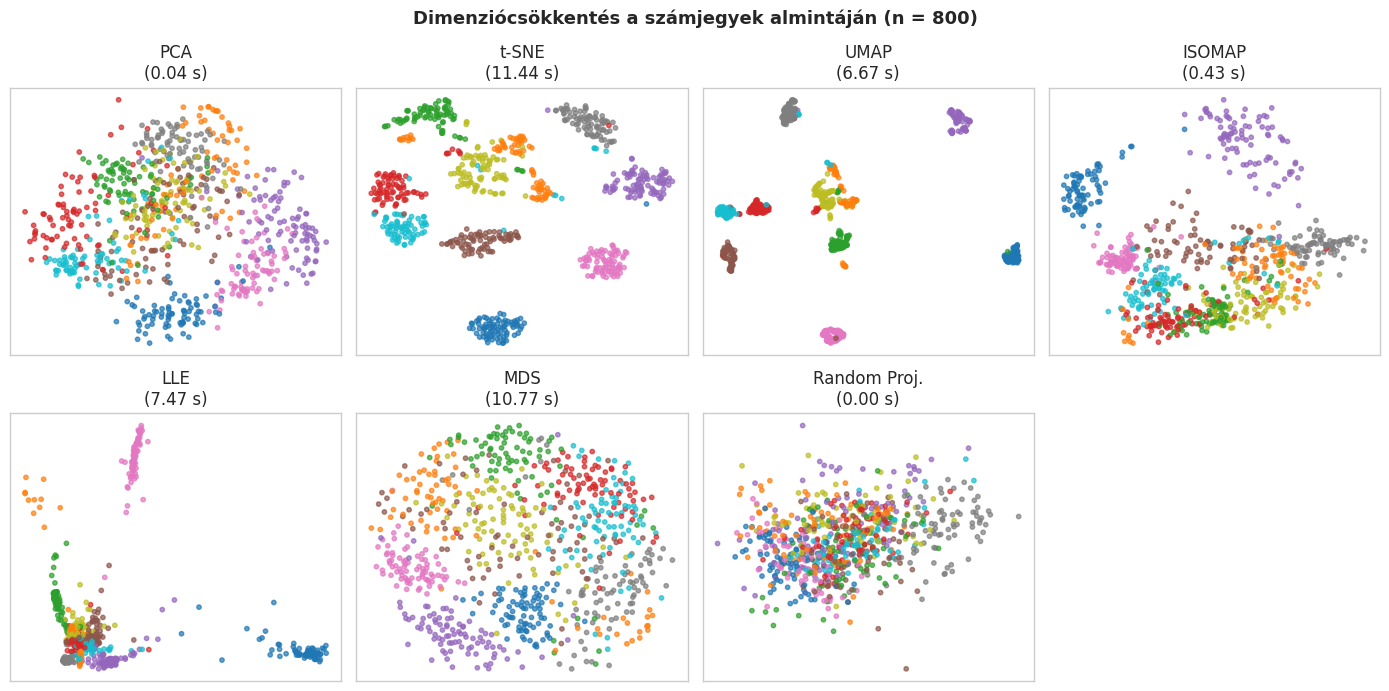


Módszer           Idő (s)   
------------------------------
Random Proj.      0.00      
PCA               0.04      
ISOMAP            0.43      
UMAP              6.67      
LLE               7.47      
MDS               10.77     
t-SNE             11.44     


In [ ]:
# Az összes módszer ugyanazon a részmintán

methods = {
    'PCA': lambda: PCA(n_components=2).fit_transform(X_dig_sub),
    't-SNE': lambda: TSNE(n_components=2, perplexity=30, init='pca',
                          learning_rate='auto', random_state=0).fit_transform(X_dig_sub),
    'UMAP': lambda: umap.UMAP(n_neighbors=15, min_dist=0.1,
                              random_state=0).fit_transform(X_dig_sub),
    'ISOMAP': lambda: Isomap(n_neighbors=10, n_components=2).fit_transform(X_dig_sub),
    'LLE': lambda: LocallyLinearEmbedding(n_neighbors=15, n_components=2,
                                          method='modified',
                                          random_state=0).fit_transform(X_dig_sub),
    'MDS': lambda: MDS(n_components=2, n_init=1, random_state=0,
                       normalized_stress='auto').fit_transform(X_dig_sub),
    'Random Proj.': lambda: GaussianRandomProjection(n_components=2,
                                                      random_state=0).fit_transform(X_dig_sub),
}

results = {}
for name, fn in methods.items():
    print(f"  {name} fut...")
    t0 = time.perf_counter()
    Z = fn()
    elapsed = time.perf_counter() - t0
    results[name] = (Z, elapsed)

# Plot rács
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, (name, (Z, t)) in zip(axes, results.items()):
    ax.scatter(Z[:, 0], Z[:, 1], c=y_dig_sub, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f'{name}\n({t:.2f} s)')
    ax.set_xticks([])
    ax.set_yticks([])

# Az utolsó cellát rejtjük el
axes[-1].axis('off')

plt.suptitle(f'Dimenziócsökkentés a számjegyek almintáján (n = {len(X_dig_sub)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'Módszer':<18}{'Idő (s)':<10}")
print('-' * 30)
for name, (Z, t) in sorted(results.items(), key=lambda kv: kv[1][1]):
    print(f"{name:<18}{t:<10.2f}")

## Döntési útmutató

| Helyzet | Ajánlott módszer |
|---------|-------------------|
| Adat előfeldolgozás ML-hez (gyorsan, megfordíthatóan) | PCA |
| Vizualizáció, lokális struktúra fontos | t-SNE vagy UMAP |
| Vizualizáció, **globális** struktúra is fontos | UMAP |
| Új adatra is alkalmazható nemlineáris vetítés | UMAP |
| Sima sokaság topológiai megőrzése | ISOMAP |
| Lokális lineáris struktúrák | LLE |
| Páronkénti távolságok pontos megőrzése | MDS |
| Nagyon nagy adat, gyors közelítés | Random Projection |
| Tanulható, folyam-szerű reprezentáció | Autoencoder |

### Általános elvek

1. **Mindig próbálj több módszert**: nincs "egy a győztes mindenre"
2. **Standardizáld az adatot** (legalábbis PCA, t-SNE, UMAP-hez)
3. **Hiperparaméter érzékenység**: t-SNE perplexity, UMAP n_neighbors / min_dist
4. **Vizualizáció ≠ ML feature**: lineáris módszereket vagy autoencodert használj a pipeline-ban
5. **Ne értelmezd túl** a t-SNE/UMAP távolságokat globálisan

## Gyakorló feladatok

### 1. feladat

Mutasd meg, hogy a klasszikus MDS, ha az inputja az euklideszi távolságmátrix, **ekvivalens** a PCA-val (azonos vetületet ad forgatás erejéig).

<details>
<summary><strong>Megoldás megjelenítése</strong></summary>

A klasszikus MDS lépései:

1. Számoljuk ki $D^2_{ij} = \|x_i - x_j\|^2$
2. **Centráljuk**: $B = -\frac{1}{2} J D^2 J$, ahol $J = I - \frac{1}{n} \mathbf{1}\mathbf{1}^T$
3. $B$ sajátfelbontása: $B = U \Lambda U^T$
4. Beágyazás: $Y = U_k \Lambda_k^{1/2}$

Megmutatható, hogy ha $X$ centrált, akkor:

$$B = X X^T$$

Ez ugyanaz, mint amit a PCA SVD-jéből kapunk: $X = U S V^T \Rightarrow X X^T = U S^2 U^T$.

Tehát az MDS sajátvektorai = PCA bal-szinguláris vektorai $U$, és a vetület $U_k S_k$, ami a PCA-vetítés $XV_k$. Csak forgatás erejéig térnek el.

</details>

### 2. feladat

Az UMAP-hoz hasonlóan a t-SNE-hez is van *parametric* (neurális hálós) variáns. Mi az előnye/hátránya az eredetihez képest?

<details>
<summary><strong>Megoldás megjelenítése</strong></summary>

A **parametric t-SNE** egy neurális hálót tanít, amelyik egy függvényt tanul $f: \mathbb{R}^d \to \mathbb{R}^k$. A háló veszteségfüggvénye a sima t-SNE KL-divergenciája.

**Előnyök**:
- Új pontot tudunk vetíteni a hálót lefuttatva (`f(x_new)`)
- Mini-batch-ekben is működik, skálázódik nagy adatra
- Folyamatos a vetítés (kis input-változás kis output-változás)

**Hátrányok**:
- A neurális háló bonyolult tanítása
- A kapacitás nem mindig elég a t-SNE struktúrák megtanulásához
- Lassabb tanítani, mint az eredetit egyszer lefuttatni kis adaton

A modern gyakorlatban ezt a szerepet sokszor az UMAP veszi át.

</details>

### 3. feladat

Az ISOMAP egy gyakori hibája, hogy ha a sokaságon **lyuk** vagy **elszakadás** van, a geodetikus távolságok rossz közelítést adnak. Adj egy konkrét példát, ahol ez kifejezetten torzítja a vetületet.

<details>
<summary><strong>Megoldás megjelenítése</strong></summary>

Példa: **két párhuzamos görbe**, amelyek egy ponton közel vannak. Ilyen lehet egy "kettős spirál": két nem összekapcsolt sokaság, amelyek a 3D-ben időnként közel kerülnek egymáshoz.

Az ISOMAP a $k$-szomszédság alapján gráfot épít. Ha két "rétegben" lévő pont véletlenül szomszéd lesz (mert lokálisan egymás közelében vannak), a gráf "összeköti" a két sokaságot. A geodetikus távolság ezután akár több külön struktúrát is összemos.

**Megoldás**: kisebb $k$-t használni; manifold-tisztító előfeldolgozást alkalmazni; vagy LLE-t/UMAP-ot használni, amelyek lokálisabbak.

</details>